In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import h5py
from keras.models import load_model, Model
from keras.layers import Conv2D
from sklearn.model_selection import train_test_split

In [2]:
# --- 1. Load the Saved Model ---
# This should match what's saved in main.ipynb
model_path = 'final_novel_attention_model.keras'

try:
    model = load_model(model_path)
    print(f"Model loaded successfully from: {model_path}")
    print(f"Model input shape: {model.input_shape}")
    print(f"Model output shape: {model.output_shape}")
except Exception as e:
    print(f"Error loading model: {e}")
    print(f"Please make sure '{model_path}' exists in the current directory.")
    print("Run main.ipynb first to train and save the model.")

2026-05-09 20:56:44.968067: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-05-09 20:56:44.968093: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-05-09 20:56:44.968096: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
2026-05-09 20:56:44.968121: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-09 20:56:44.968133: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model loaded successfully from: final_novel_attention_model.keras
Model input shape: (None, 96, 96, 3)
Model output shape: (None, 1)


In [3]:
# --- 2. Load and Preprocess Test Data for Analysis ---
with h5py.File('all_patches.hdf5', 'r') as f:
    images = f['ct_slices'][:]
    labels = f['slice_class'][:]

target_size = (96, 96)
images = np.stack([images] * 3, axis=-1)
images = tf.image.resize(images, target_size)
images = images.numpy().astype('float32') / 255.0
labels = labels.reshape(-1)

X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.3, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)
print(f"Test set loaded with shape: {X_test.shape}")


Test set loaded with shape: (1004, 96, 96, 3)


In [ ]:
# --- 3. Corrected Grad-CAM Function ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Ensure img_array has batch dimension
    if len(img_array.shape) == 3:
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    
    # Create gradient model
    grad_model = Model(
        model.input,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        # Forward pass
        last_conv_layer_output, preds = grad_model(img_array)
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        
        # For binary classification, use the sigmoid output directly
        class_channel = preds[:, 0]  # Binary classification output

    # Compute gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)
    
    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight the channels by the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    
    return heatmap.numpy()

✅ Using 'Conv_1_bn' as the last convolutional layer for Grad-CAM.


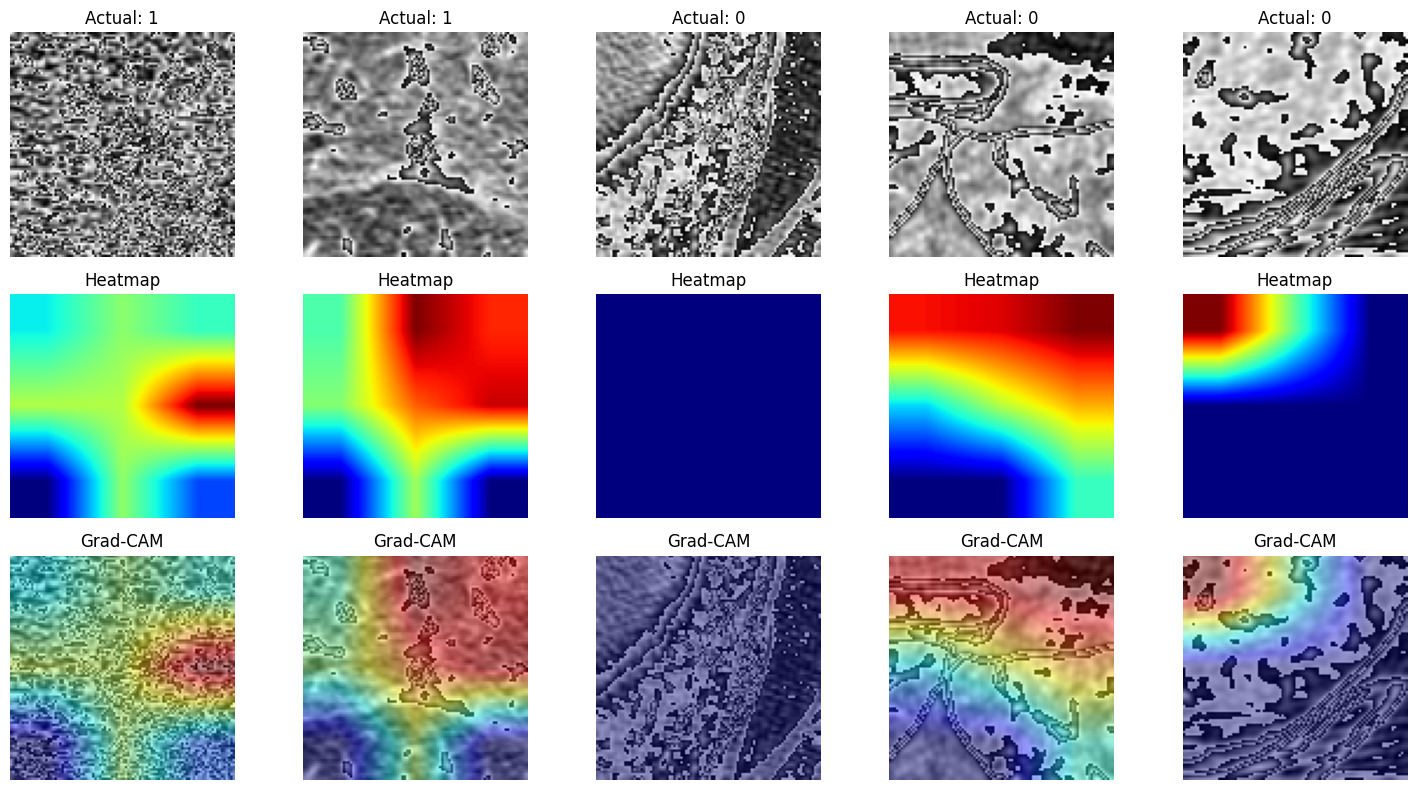

In [5]:
# --- 4. Generate and Display Grad-CAM Heatmaps (Corrected for MobileNetV2) ---
# MobileNetV2 doesn't use Conv2D, it uses DepthwiseConv2D and other layers
# We need to find the last convolutional-type layer

last_conv_layer_name = None

# Try to find the last conv layer (MobileNetV2 specific)
for layer in reversed(model.layers):
    # MobileNetV2 uses these layer types
    if hasattr(layer, 'output') and len(layer.output.shape) == 4:
        # This is a layer with spatial dimensions (H, W)
        if 'conv' in layer.name.lower() or 'expanded' in layer.name.lower():
            last_conv_layer_name = layer.name
            break

# If no specific conv layer found, use a known MobileNetV2 layer
if last_conv_layer_name is None:
    # MobileNetV2's last convolutional layer before global pooling
    for layer in model.layers:
        if 'out_relu' in layer.name or 'Conv_1' in layer.name:
            last_conv_layer_name = layer.name
            break

# Fallback: use the layer before GlobalAveragePooling2D
if last_conv_layer_name is None:
    for i, layer in enumerate(model.layers):
        if 'global_average_pooling' in layer.name.lower():
            last_conv_layer_name = model.layers[i-1].name
            break

if last_conv_layer_name is None:
    print("❌ Could not find a suitable convolutional layer for Grad-CAM.")
    print("Available layers:")
    for layer in model.layers[-10:]:
        print(f"  - {layer.name} ({layer.__class__.__name__})")
else:
    print(f"✅ Using '{last_conv_layer_name}' as the last convolutional layer for Grad-CAM.")

    num_samples_to_show = 5
    sample_images = X_test[:num_samples_to_show]
    sample_labels = y_test[:num_samples_to_show]
    
    plt.figure(figsize=(15, 8))
    for i in range(num_samples_to_show):
        img_array = sample_images[i]
        
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

        # Ensure all images are in the correct format
        img = (sample_images[i] * 255).astype(np.uint8)
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)
        
        # Original Image
        plt.subplot(3, num_samples_to_show, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Actual: {int(sample_labels[i])}')
        plt.axis('off')
        
        # Heatmap
        plt.subplot(3, num_samples_to_show, i + 1 + num_samples_to_show)
        plt.imshow(heatmap_resized, cmap='jet')
        plt.title('Heatmap')
        plt.axis('off')

        # Grad-CAM Overlay
        plt.subplot(3, num_samples_to_show, i + 1 + 2 * num_samples_to_show)
        plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
        plt.title('Grad-CAM')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()